In [2]:
pip install dlisio

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from dlisio import dlis
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows',500)

In [3]:
import dlisio
dlisio.__version__

'1.0.3'

Loading a DLIS file

In [4]:
f, *tail = dlis.load('/Users/apple/Downloads/welldata/2011/SCHOONEBEEK-2302/structured/logdocuments/dgr_ewr_09apr11.dlis')

In [5]:
print(f)

LogicalFile(GEOLOAD.1)


In [6]:
print(tail)

[LogicalFile(GEOLOAD.1)]


In [7]:
f.channels

[Channel(DEPT),
 Channel(CGRC),
 Channel(DGXT),
 Channel(SFXE),
 Channel(CEXP),
 Channel(CEXA),
 Channel(CESP),
 Channel(CESA),
 Channel(CEMP),
 Channel(CEMA),
 Channel(CEDP),
 Channel(CEDA),
 Channel(STEM),
 Channel(TVD),
 Channel(SRAT)]

In [8]:
f.describe()

------------
Logical File
------------
Description : LogicalFile(GEOLOAD.1)
Frames      : 1
Channels    : 15

Known objects
--
TOOL        : 15
COMMENT     : 3
FRAME       : 1
PARAMETER   : 104
ORIGIN      : 1
FILE-HEADER : 1
CHANNEL     : 15

Unknown objects
--
280-FRAMESTEP-INFO : 1


Viewing the file's metadata

1.Data Origin

In [9]:
origin, *origin_tail = f.origins

In [11]:
origin_tail

[]

In [12]:
origin.describe()

------
Origin
------
name   : 0
origin : 2
copy   : 0

Logical file ID          : GEOLOAD.1
File set name and number : NAM/SCHOONEBEEK 2302 / 230093273
File number and type     : 1 / PLAYBACK

Field                   : Schoonebeek
Well (id/name)          : 110000900177 / Schoonebeek 2302
Produced by (code/name) : 280 / Halliburton
Produced for            : NAM
Order number            : HO-MW-0007978973
Created                 : 2011-04-26 17:00:57

Created by : GEOLOAD, (version: DEVELOPMENT)


2.Frames

In [13]:
f.frames

[Frame(50)]

In [15]:
#loop over each frame within a file
for frame in f.frames:
    #search through the channels to look for the index and obtain the units
    for channel in frame.channels:
        if channel.name == frame.index:
            depth_units = channel.units

print(f'Frame Name: \t\t {frame.name}')
print(f'Index Type: \t\t {frame.index_type}')
print(f'Depth Interval: \t {frame.index_min} - {frame.index_max} {depth_units}')
print(f'Depth Spacing: \t\t {frame.spacing} {depth_units}')
print(f'Direction: \t\t {frame.direction}')
print(f'Num of Channels: \t {len(frame.channels)}')
print(f'Channel Names: \t\t {str(frame.channels)}')

print('\n\n')

Frame Name: 		 50
Index Type: 		 BOREHOLE-DEPTH
Depth Interval: 	 None - None m
Depth Spacing: 		 0.1 m
Direction: 		 INCREASING
Num of Channels: 	 15
Channel Names: 		 [Channel(DEPT), Channel(CGRC), Channel(DGXT), Channel(SFXE), Channel(CEXP), Channel(CEXA), Channel(CESP), Channel(CESA), Channel(CEMP), Channel(CEMA), Channel(CEDP), Channel(CEDA), Channel(STEM), Channel(TVD), Channel(SRAT)]





Parameters within the DLIS file

In [16]:
def summary_dataframe(object, **kwargs):
    # Create an empty dataframe
    df = pd.DataFrame()

    # Iterate over each of the keyword arguments
    for i, (key, value) in enumerate(kwargs.items()):
        list_of_values = []

        # Iterate over each parameter and get the relevant key
        for item in object:
            # Account for any missing values.
            try:
                x = getattr(item, key)
                list_of_values.append(x)
            except:
                list_of_values.append('')
                continue

        # Add a new column to our data frame
        df[value] = list_of_values

    # Sort the dataframe by column 1 and return it
    return df.sort_values(df.columns[0])


In [17]:
param_df = summary_dataframe(
    f.parameters,
    name='Name',
    long_name='Long Name',
    values='Values'
)

# Hiding people's names that may be in parameters.
# These two lines can be commented out to show them
mask = param_df['Name'].isin(['R8', 'RR1', 'WITN', 'ENGI'])
param_df = param_df[~mask]

param_df


,Name,Long Name,Values
27,AGAP,AIR GAP,[0.0]
43,APD,DEPTH ABOVE PD,[21.3700008392334]
4,APIN,API S/N,[110000900177]
52,AZTC,AZM TOTAL CORR,[-0.33799999952316284]
24,CMER,CENTRL MERIDIAN,[0.0]
3,CN,CUSTOMER NAME,[NAM]
9,CTRY,COUNTRY NAME,[Netherlands]
12,DCON,DIRECTNL CONTR,[DrillTec]
72,DDSV,DDS PkZ 30-50g,[126.0]
86,DDSV,DDS AgvX Total,[656.2000732421875]


Viewing Channels Information

In [18]:
channels = summary_dataframe(f.channels,name ='Name', long_name="Long Name", values="Values")
channels

,Name,Long Name,Values
11,CEDA,CEDA/Corrected Deep Attenuation Resistivity,
10,CEDP,CEDP/Corrected Deep Phase Resistivity,
9,CEMA,CEMA/Corrected Medium Attenuation Resistivity,
8,CEMP,CEMP/Corrected Medium Phase Resistivity,
7,CESA,CESA/Corrected Shallow Attenuation Resistivity,
6,CESP,CESP/Corrected Shallow Phase Resistivity,
5,CEXA,CEXA/Corrected Extra Shallow Attenuation Resis...,
4,CEXP,CEXP/Corrected Extra Shallow Phase Resistivity,
1,CGRC,CGRC/Combined Gamma Ray,
0,DEPT,DEPT/Depth,


Viewing Tools Information which were used

In [19]:
tools = summary_dataframe(f.tools, name='Name',description="Description")
tools

,Name,Description
0,ABI_ID,ABI
1,DDSR_DGR_ID,DDSr-DGR
2,DGR_ID,DGR
13,Desc Rec Depth,Desc Rec Depth
10,EWR 09T,EWR 09T
11,EWR 15T,EWR 15T
12,EWR 27T,EWR 27T
9,EWR 39T,EWR 39T
3,EWR_SOLAR_ID,EWR-Solar
4,HCIM_ID,HCIM


In [21]:
pwd_id = f.object('TOOL','PWD_ID')
pwd_id_params = summary_dataframe(pwd_id.parameters, name="Name", long_name="Long Name", values="Values")

In [22]:
pwd_id_params

,Name,Long Name,Values
0,DFB,Dist From Bit,[80.57742309570312]
3,SNC,SN Collar,[11271805]
2,SNIN,SN Insert,[10507439]
1,SP1,Sample Period 1,[2.0]


Working with data objects

In [23]:
frame1=f.object('FRAME','50')

In [24]:
frame1

Frame(50)

In [27]:
dtc = f.object('CHANNEL', 'CEDA')

# Print out the properties of the channel/curve
print(f'Name: \t\t{dtc.name}')
print(f'Long Name: \t{dtc.long_name}')
print(f'Units: \t\t{dtc.units}')
print(f'Dimension: \t{dtc.dimension}')  # if >1, then data is an array


Name: 		CEDA
Long Name: 	CEDA/Corrected Deep Attenuation Resistivity
Units: 		ohmm
Dimension: 	[1]


Plotting data

In [28]:
curves = frame1.curves()

In [29]:
curves

array([(  1, 917. , -999.25    , -999.25    , -999.25    , -999.25     , -9.9925000e+02, -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25    , 724.9929 , -9.9925000e+02),
       (  2, 917.1, -999.25    , -999.25    , -999.25    , -999.25     , -9.9925000e+02, -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25    , 725.0294 , -9.9925000e+02),
       (  3, 917.2, -999.25    , -999.25    , -999.25    , -999.25     , -9.9925000e+02, -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25    , 725.0642 , -9.9925000e+02),
       (  4, 917.3, -999.25    , -999.25    , -999.25    , -999.25     , -9.9925000e+02, -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25     , -999.25    , 725.10425, -9.9925000e+02),
       (  5, 917.4, -999.25    , -999.25    , -999.25    , -999.25     , -9.9925000e+02, -999.25     , -999.25     , -999.25     , -999.25     ,

In [33]:
depth = curves['TVD']*.00254
dtco = curves['CGRC']
dtsm = curves['STEM']

print(f'{depth.min()}-{depth.max()}')

1.8414820432662964-1.8767987489700317


In [34]:
dtco

array([-999.25    , -999.25    , -999.25    , -999.25    , -999.25    ,
       -999.25    , -999.25    , -999.25    , -999.25    , -999.25    ,
       -999.25    , -999.25    , -999.25    , -999.25    , -999.25    ,
       -999.25    , -999.25    , -999.25    , -999.25    , -999.25    ,
       -999.25    , -999.25    , -999.25    , -999.25    , -999.25    ,
       -999.25    , -999.25    , -999.25    , -999.25    , -999.25    ,
       -999.25    ,   65.66185 ,   69.546776,   71.68739 ,   76.77156 ,
         72.139984,   71.14061 ,   70.667564,   69.96225 ,   69.96225 ,
         74.71242 ,   74.80668 ,   70.403046,   62.426487,   62.426487,
         62.426487,   60.54255 ,   58.658615,   56.774677,   56.774677,
         56.774677,   67.136345,   77.49802 ,   77.49802 ,   71.888466,
         63.515327,   62.774837,   63.404278,   72.77833 ,   63.637363,
         60.54255 ,   62.426487,   62.426487,   50.440033,   58.765144,
         65.115585,   67.93125 ,   65.03525 ,   55.684174,   53.

In [35]:
dtsm

array([-999.25    , -999.25    , -999.25    , -999.25    , -999.25    ,
       -999.25    , -999.25    ,   32.27181 ,   32.470707,   32.470707,
         32.470707,   32.442722,   32.35595 ,   32.33324 ,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.470707,
         32.470707,   32.470707,   32.470707,   32.470707,   32.

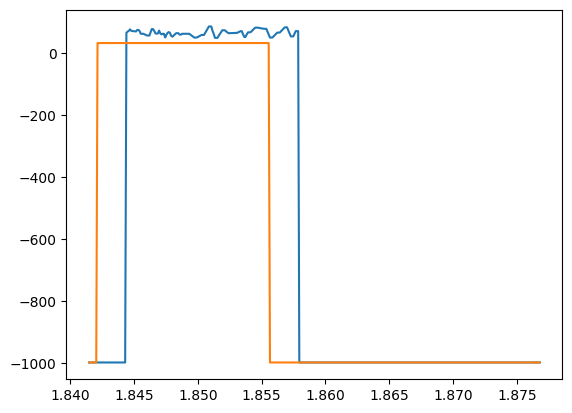

In [36]:
plt.plot(depth,dtco)
plt.plot(depth,dtsm)